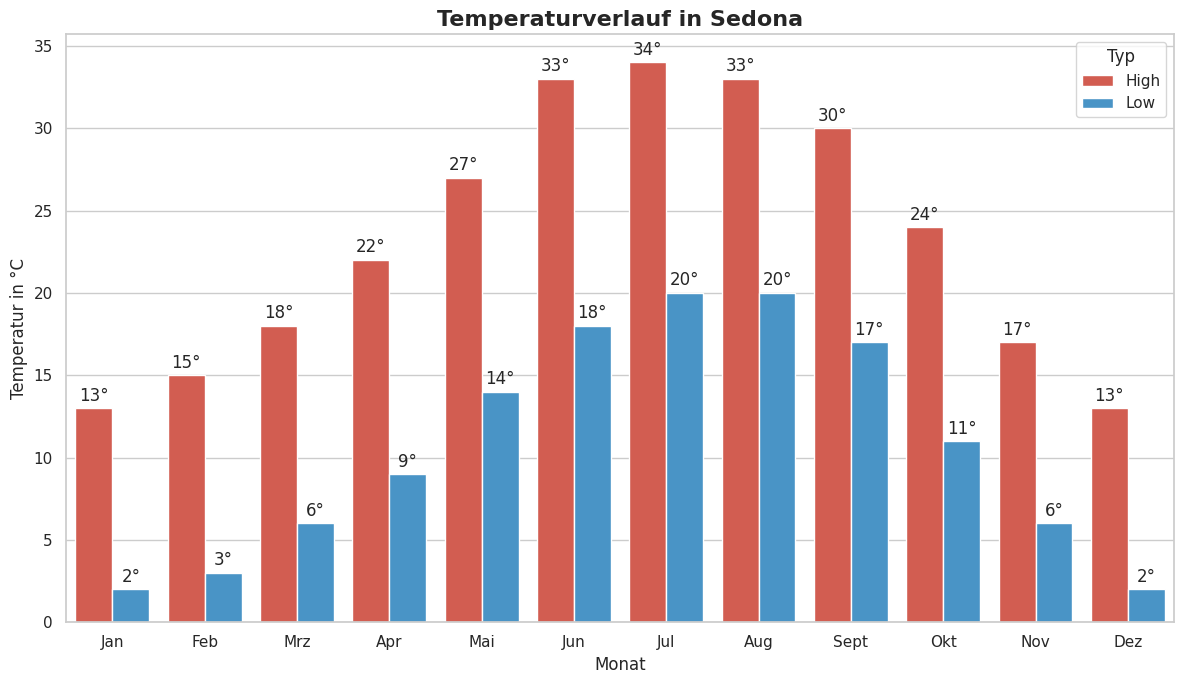

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pymongo import MongoClient

# 1. Verbindung
client = MongoClient("mongodb://localhost:27017/")
db = client["USA"]
col = db["states"]

ciudad_name = "Sedona"

# 2. Daten abrufen
res = col.find_one({"Town": ciudad_name})

if res:
    # Wir extrahieren die Dictionaries direkt
    highs = res.get('Temperature high', {})
    lows = res.get('Temperature low', {})

    # Wir erstellen ein sauberes DataFrame aus den Dictionaries
    # Die Monate sind hier die Index-Keys (Jan, Feb, ...)
    df = pd.DataFrame({
        'Monat': list(highs.keys()),
        'High': list(highs.values()),
        'Low': list(lows.values())
    })

    # 3. "Schmelzen" für Seaborn
    df_plot = df.melt(id_vars='Monat', value_vars=['High', 'Low'], 
                      var_name='Typ', value_name='Temperatur')

    # 4. Visualisierung
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    chart = sns.barplot(
        data=df_plot,
        x='Monat',
        y='Temperatur',
        hue='Typ',
        palette=['#e74c3c', '#3498db'] # Rot für High, Blau für Low
    )

    # Werte über die Balken schreiben
    for p in chart.patches:
        height = p.get_height()
        if height > 0:
            chart.annotate(f'{height:.0f}°', 
                           (p.get_x() + p.get_width() / 2., height), 
                           ha='center', va='center', 
                           xytext=(0, 9), 
                           textcoords='offset points')

    plt.title(f'Temperaturverlauf in {ciudad_name}', fontsize=16, fontweight='bold')
    plt.ylabel('Temperatur in °C')
    plt.tight_layout()

    # 5. Speichern
    filename = f"Temperaturverlauf_{ciudad_name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()
else:
    print("Stadt nicht gefunden oder keine Daten verfügbar.")